In [1]:
import matplotlib.pyplot as plt  # Plotting library
import xarray as xr 
import numpy as np 
import scipy 
from file import getGRIB 
import cmaps as cmap 
import warnings
from helper import thetae, theta, moistEnthalpy, sat_specific_humidity, density
from matplotlib import patheffects as pe 
import cartopy, cartopy.crs as ccrs 
import numpy as np
import cmaps as cmap
import bdeck as bdeck 
from matplotlib import rcParams 
import matplotlib.patheffects as pe
from scipy.ndimage import gaussian_filter
import cartopy.feature as cfeature
import cartopy.mpl.ticker as cticker
import satcmaps as cmp2
import boto3
from botocore import UNSIGNED
from botocore.config import Config
warnings.filterwarnings("ignore")

def Gradient2D_m(data, short = False):
    if short == True:
        lon = 'lon'
        lat = 'lat'
    else:
        lon = 'longitude'
        lat = 'latitude'
    # Define gradient vector as <fx, fy>
    # Compute the derivative of the dataset, A, in x and y directions, accounting for dimensional changes due to centered differencing
    dAx = data.diff(lon)[1:]
    dAy = data.diff(lat)[1:]

    # Compute the derivative of both the x and y coordinates
    dx = data[lon].diff(lon) * np.cos(np.deg2rad(data[lat])) * (np.pi/180*6_371_000)
    dy = data[lat].diff(lat) * (np.pi/180*6_371_000)

    # Return dA/dx and dA/dy, where A is the original dataset
    return dAx / dx, dAy / dy

def makeMap(loc, size, lc = 'black', interval = 1, center = 0):
    labelsize = 8
    fig = plt.figure(figsize = size)

    # Add the map and set the extent
    ax = plt.axes(projection=ccrs.PlateCarree(central_longitude = center))
    ax.set_frame_on(False)
    
    # Add state boundaries to plot
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), edgecolor = lc, linewidth = 0.5)
    ax.add_feature(cfeature.BORDERS.with_scale('50m'), edgecolor = lc, linewidth = 0.5)
    ax.add_feature(cfeature.STATES.with_scale('50m'), edgecolor = lc, linewidth = 0.5)

    if loc[0] > 180:
        ax.set_xticks(np.arange(round(loc[0]) - 360, (round(loc[1]) - 360) + interval, interval), crs=ccrs.PlateCarree())
    else:
        ax.set_xticks(np.arange(round(loc[0]), round(loc[1]) + interval, interval), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(round(loc[2]), round(loc[3]) + interval, interval), crs=ccrs.PlateCarree())
    ax.yaxis.set_major_formatter(cticker.LatitudeFormatter())
    ax.xaxis.set_major_formatter(cticker.LongitudeFormatter())
    ax.tick_params(axis='both', labelsize=labelsize, left = False, bottom = False)
    ax.grid(linestyle = '--', alpha = 0.5, color = lc, linewidth = 0.5, zorder = 9)
    ax.set_extent(loc, crs=ccrs.PlateCarree())

    return ax

def rePoPolar(dataset, name):
    x = dataset.longitude.values - np.nanmean(dataset.longitude.values)
    y = dataset.latitude.values - np.nanmean(dataset.latitude.values)
    x, y = np.meshgrid(x, y)

    R = 6371.0
    cphi = np.cos(np.deg2rad(y))
    x = R * np.deg2rad(x) * cphi
    y = R * np.deg2rad(y)

    r = np.sqrt(x**2 + y**2)
    t = np.arctan2(y, x)

    rBins = np.linspace(np.nanmin(r), np.nanmax(r), 360)
    tBins = np.linspace(0, 2 * np.pi, 720)

    R, T = np.meshgrid(rBins, tBins)
    newX, newY = R * np.cos(T), R * np.sin(T)
    gridded_data = scipy.interpolate.griddata((x.flatten(), y.flatten()), dataset.values.flatten(), (newX.flatten(), newY.flatten()), method='nearest')

    polar = xr.Dataset(
        {
            name: (('r', 'theta'), gridded_data.reshape(R.shape).transpose())
        },
        coords={
            'r': rBins,
            'theta': tBins
        }
    )

    return polar

def labels(ax, flag = False):
    ax.set_yticklabels(['', '50km', '', '150km', '', '250km', ''], fontfamily = 'Courier New', alpha = 0.75, path_effects=[pe.withStroke(linewidth=2.25, foreground="white")])
    ax.set_xticklabels(['E', 'NE', 'N', 'NW', 'W', 'SW', 'S', 'SE'])#, path_effects=[pe.withStroke(linewidth=2.25, foreground="white")])

    # ax.set_frame_on(False)
    ax.grid(linestyle = '-', alpha = 0.25, color = 'black', linewidth = 0.5, zorder = 9)
    # ax.set_yticklabels([])


In [2]:
bucket = 'noaa-nws-hafs-pds'
def getAWSFile(storm, date, init, fhour, model, t = 'storm'):
    s3_client = boto3.client('s3', config=Config(signature_version=UNSIGNED))
    paginator = s3_client.get_paginator('list_objects_v2')
    prefix = f'hfs{model.lower()}/{date}/{init[:2]}/'

    response_iterator = paginator.paginate(
        Bucket = bucket,
        Delimiter='/',
        Prefix = prefix,
    )

    files = []
    for page in response_iterator:
        for object in page['Contents']:
            if storm.lower() in object['Key'] and f'{t}.atm.f{fhour.zfill(3)}' in object['Key']:
                file = object['Key']
                files.append(file)
    print(files)
    
    s3_client.download_file(bucket, files[0], r"C:\Users\deela\Downloads\\gfsGRIB.grib2")    
    # s3_client.download_file(bucket, files[1], r"C:\Users\deela\Downloads\\gfsGRIB.grib2.idx")    

def getData(storm, date, init, fhour, var, level, model, group = 'isobaricInhPa', newFile = True, t = 'storm'):
    date = date.split('/')
    date = f'{date[2]}{date[0].zfill(2)}{date[1].zfill(2)}'
    
    if newFile == True:
        try:
            getAWSFile(storm, date, init, fhour, model, t = t)
        except Exception as e:
            link = f'https://nomads.ncep.noaa.gov/pub/data/nccf/com/hafs/prod/hfs{model}.{date}/{init[:2]}/{storm.lower()}.{date}{init[:2]}.hfs{model}.{t}.atm.f{str(fhour).zfill(3)}.grb2'
            print(link)
            gfsGRIB = getGRIB(link, 'gfsGRIB.grib2')

    try:
        if group in ['surface', 'meanSea', 'atmosphereSingleLayer']:
            dataset = xr.open_dataset(r"C:\Users\deela\Downloads\gfsGRIB.grib2", backend_kwargs={"filter_by_keys": {'stepType': 'instant', "typeOfLevel": group}})
        elif level.lower() in ['surface', 'sfc']:
            group = 'surface'
            dataset = xr.open_dataset(r"C:\Users\deela\Downloads\gfsGRIB.grib2", backend_kwargs={"filter_by_keys": {'stepType': 'instant', "typeOfLevel": group}})
        elif level.lower() in ['2m', '10m']:
            group = 'heightAboveGround'
            dataset = xr.open_dataset(r"C:\Users\deela\Downloads\gfsGRIB.grib2", backend_kwargs={"filter_by_keys": {"typeOfLevel": group, 'level' : int(level[:-1])}})
        elif level.lower() in ['3000m']:
            group = 'heightAboveGroundLayer'
            dataset = xr.open_dataset(r"C:\Users\deela\Downloads\gfsGRIB.grib2", backend_kwargs={"filter_by_keys": {"typeOfLevel": group, 'level' : int(level[:-1])}})
        elif level.lower() == 'tropopause':
            group = 'tropopause'
            dataset = xr.open_dataset(r"C:\Users\deela\Downloads\gfsGRIB.grib2", backend_kwargs={"filter_by_keys": {"typeOfLevel": 'tropopause'}})        
        else:
            dataset = xr.open_dataset(r"C:\Users\deela\Downloads\gfsGRIB.grib2", backend_kwargs={"filter_by_keys": {"typeOfLevel": group}})
    except:
        dataset = xr.open_dataset(r"C:\Users\deela\Downloads\gfsGRIB.grib2", backend_kwargs={"filter_by_keys": {"typeOfLevel": group}})
            
    levels = []
    if type(level) == str or type(level) == int:
        levels = [level for v in var]
    else:
        levels = level 

    data = []
    for i, v in enumerate(var):
        if group == 'isobaricInhPa':
            data.append(dataset[v].sel(isobaricInhPa = levels[i]))
        else:
            if group == 'heightAboveGround':
                if v.lower() == 't':
                    v = 't2m'
                elif v.lower() == 'r':
                    v = 'r2'
                elif v.lower() == 'q':
                    v = 'sh2'
                elif v.lower() == 'u':
                    v = 'u10'
                elif v.lower() == 'v':
                    v = 'v10'
            data.append(dataset[v])

    return data


In [3]:
def computeVentilation(tData, qData, uData, vData, wData, level):
    r = 300
    teData = thetae(tData, int(level), 1000, qData, dew = False)
    dData = density(tData, qData, int(level), q = True)
    te = rePoPolar(teData, 'data')
    te = te['data'].sel(r = slice(0, r))
    d = rePoPolar(dData, 'data')
    d = d['data'].sel(r = slice(0, r))
    u = rePoPolar(uData, 'data')
    u = u['data'].sel(r = slice(0, r))
    v = rePoPolar(vData, 'data')
    v = v['data'].sel(r = slice(0, r))
    w = rePoPolar(wData, 'data')
    w = w['data'].sel(r = slice(0, r))

    R, T = np.meshgrid(u.r, v.theta, indexing = 'ij') 
    radialWind = (u * np.cos(T)) + (v * np.sin(T))
    # radialWind.values = np.flip(radialWind.values, axis = 1)
    radPer = radialWind - radialWind.mean('theta')

    # te.values = np.flip(te.values, axis = 1)
    thtPer = te - te.mean('theta')

    thetaCoord = u.theta 
    rCoord = u.r
    vent = thtPer * radPer * d

    return thetaCoord, rCoord, vent, radialWind, te, w, thtPer, radPer

def ventPlot(storm, date, init, fhour, level = 850, model = 'a'):
    data = getData(storm, date, init, fhour, ['t', 'q', 'u', 'v', 'wz'], level, model)
    thetaCoord, rCoord, vent, radialWind, te, w, tPer, rPer = computeVentilation(data[0], data[1], data[2], data[3], data[4], level)

    fig, axes = plt.subplots(2, 2, subplot_kw={'projection': 'polar'}, figsize=(18, 15))
    axes[0, 0].pcolormesh(thetaCoord, rCoord, radialWind, cmap = cmap.tempAnoms6(), vmin = -50, vmax = 50)
    labels(axes[0, 0])

    c = axes[0, 1].pcolormesh(thetaCoord, rCoord, vent, cmap = cmap.tempAnoms6(), vmin = -50, vmax = 50)
    mask = (rPer < 0) & (tPer < 0) & (vent > 2.5)
    axes[0, 1].contour(thetaCoord, rCoord, mask, levels=[0.5], colors='black')
    labels(axes[0, 1])

    ca = axes[1, 0].pcolormesh(thetaCoord, rCoord, te, cmap = cmap.probs4(), vmin = 320, vmax = 350)
    labels(axes[1, 0])

    c = axes[1, 1].pcolormesh(thetaCoord, rCoord, w * 60, cmap = cmap.tempAnoms6(), vmin = -50, vmax = 50)
    labels(axes[1, 1])

    cbar = fig.colorbar(c, ax=axes, orientation='vertical', aspect=50, pad=0.04)
    cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)

    pos = axes[1, 0].get_position()

    cbar_ax = fig.add_axes([
        pos.x0,            
        pos.y0 - 0.025,     
        pos.width,         
        0.005               
    ])

    cbar = fig.colorbar(ca, cax=cbar_ax, orientation='horizontal')

    fig.text(0.11, 0.94, f'HAFS-{model.upper()} {level} hPa Ventilation Diagnostic\nInitialization: {date} at {init}z', fontweight='bold', fontsize=12, ha='left', va='top')
    fig.text(0.455, 0.94, f'Forecast Hour: {fhour}', fontsize=12, ha='center', va='top')
    fig.text(0.79, 0.94, f'{storm.upper()}\nDeelan Jariwala', fontsize=12, ha='right', va='top')

    axes[0, 0].set_title(f'Radial Wind (m/s)', fontsize=10)
    axes[0, 1].set_title(f'Ventilation', fontsize=10)
    axes[1, 0].set_title(f'Theta-E (K)', fontsize=10)
    axes[1, 1].set_title(f'Vertical Velocity (m/min)', fontsize=10)

    plt.savefig(r"C:\Users\deela\Downloads\ventRealTime.png", dpi = 200, bbox_inches = 'tight')
    plt.close()


In [ ]:
def hafsCrossSectionPlot(storm, date, init, fhour, var, dir = 'h', model = 'a'):
    lc = 'black'
    rcParams['font.family'] = 'Courier New'
    level = np.arange(100, 1025, 25)
    if var.lower() == 'temp':
        data = getData(storm, date, init, fhour, ['t'], [level], model)[0] - 273.15
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)

        if dir.lower() == 'h':
            data = data.sel(latitude = lat, method = 'nearest')
            data = data.sel(longitude = slice(lon - 2.5, lon + 2.5))
        elif dir.lower() == 'v':
            data = data.sel(latitude = slice(lat - 2.5, lat + 2.5))
            data = data.sel(longitude = lon, method = 'nearest')
        vmin = -80
        vmax = 40
        cmp = cmap.tempC()
        level = f'{level} hPa'
        longName = 'Temperature (C)'
    elif var.lower() == 'thetae':
        data = getData(storm, date, init, fhour, ['t', 'q'], [level, level], model)
        data = thetae(data[0], data[0].isobaricInhPa, 1000, data[1], dew = False)
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)

        if dir.lower() == 'h':
            data = data.sel(latitude = lat, method = 'nearest')
            data = data.sel(longitude = slice(lon - 2.5, lon + 2.5))
        elif dir.lower() == 'v':
            data = data.sel(latitude = slice(lat - 2.5, lat + 2.5))
            data = data.sel(longitude = lon, method = 'nearest')
        vmin = 300
        vmax = 400
        cmp = cmap.probs7()
        longName = 'Equivalent Potential Temperature (K)'
    elif var.lower() == 'theta':
        data = getData(storm, date, init, fhour, ['t'], [level], model)
        data = theta(data[0], data[0].isobaricInhPa, 1000)
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)

        if dir.lower() == 'h':
            data = data.sel(latitude = lat, method = 'nearest')
            data = data.sel(longitude = slice(lon - 2.5, lon + 2.5))
        elif dir.lower() == 'v':
            data = data.sel(latitude = slice(lat - 2.5, lat + 2.5))
            data = data.sel(longitude = lon, method = 'nearest')
        vmin = 275
        vmax = 425
        cmp = cmap.longTemp()
        longName = 'Potential Temperature (K)'
    elif var.lower() == 'vvel':
        data = getData(storm, date, init, fhour, ['wz'], [level], model)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)

        if dir.lower() == 'h':
            data = data.sel(latitude = lat, method = 'nearest')
            data = data.sel(longitude = slice(lon - 2.5, lon + 2.5))
        elif dir.lower() == 'v':
            data = data.sel(latitude = slice(lat - 2.5, lat + 2.5))
            data = data.sel(longitude = lon, method = 'nearest')
        vmin = -10
        vmax = 10
        cmp = cmap.tempAnoms8()
        longName = 'Vertical Velocity (m/s)'
    elif var.lower() == 'rh':
        data = getData(storm, date, init, fhour, ['r'], [level], model)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)

        if dir.lower() == 'h':
            data = data.sel(latitude = lat, method = 'nearest')
            data = data.sel(longitude = slice(lon - 2.5, lon + 2.5))
        elif dir.lower() == 'v':
            data = data.sel(latitude = slice(lat - 2.5, lat + 2.5))
            data = data.sel(longitude = lon, method = 'nearest')
        vmin = 0
        vmax = 100
        cmp = cmap.relh()
        longName = 'Relative Humidity (%)'
    elif var.lower() == 'absv':
        data = getData(storm, date, init, fhour, ['absv'], [level], model)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)

        if dir.lower() == 'h':
            data = data.sel(latitude = lat, method = 'nearest')
            data = data.sel(longitude = slice(lon - 2.5, lon + 2.5))
        elif dir.lower() == 'v':
            data = data.sel(latitude = slice(lat - 2.5, lat + 2.5))
            data = data.sel(longitude = lon, method = 'nearest')
        vmin = -0.00025
        vmax = 0.00025
        cmp = cmap.pressure3()
        longName = 'Absolute Vorticity (1/s)'
    elif var.lower() == 'tadv':
        data = getData(storm, date, init, fhour, ['u', 'v', 't'], [level, level, level], model)
        lon, lat = np.nanmean(data[0].longitude.values), np.nanmean(data[0].latitude.values)
        u, v, t = data[0], data[1], data[2]

        fx, fy = Gradient2D_m(t, False)
        data = (-(u * fx + v * fy)) * 3600

        data.values = gaussian_filter(data.values, sigma = 5, axes = (1, 2))
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)

        if dir.lower() == 'h':
            data = data.sel(latitude = lat, method = 'nearest')
            data = data.sel(longitude = slice(lon - 2.5, lon + 2.5))
        elif dir.lower() == 'v':
            data = data.sel(latitude = slice(lat - 2.5, lat + 2.5))
            data = data.sel(longitude = lon, method = 'nearest')
        vmin = -20
        vmax = 20
        cmp = cmap.tempAnoms()
        longName = 'Temperature Advection (K/h)'
    else:#elif var.lower() == 'wind':
        data = getData(storm, date, init, fhour, ['u', 'v'], [level, level], model)
        data = ((data[0]**2 + data[1]**2)**0.5) * 1.94384
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)

        if dir.lower() == 'h':
            data = data.sel(latitude = lat, method = 'nearest')
            data = data.sel(longitude = slice(lon - 2.5, lon + 2.5))
        elif dir.lower() == 'v':
            data = data.sel(latitude = slice(lat - 2.5, lat + 2.5))
            data = data.sel(longitude = lon, method = 'nearest')
        vmin = 0
        vmax = 160
        cmp = cmap.wind()
        longName = 'Wind Speed (kt)'

    if dir.lower() == 'h':
        dirLong = 'E to W'
    elif dir.lower() == 'v':
        dirLong = 'N to S'

    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes()

    ax.tick_params(axis='both', labelsize=8, left = False, bottom = False)
    ax.grid(linestyle = '--', alpha = 0.5, color = 'black', linewidth = 0.5, zorder = 9)
    ax.set_ylabel('Height (hPa)', weight = 'bold', size = 9)
    ax.set_xlabel('Distance', weight = 'bold', size = 9)
    ax.invert_yaxis()
    ax.set_yscale('log')
    ax.set_yticks([1000, 850, 700, 500, 200, 100])
    ax.set_yticklabels(['1000', '850', '700', '500', '200', '100'])
    ax.minorticks_off()

    if dir.lower() == 'h':
        c = ax.contourf(data.longitude, data.isobaricInhPa, data, levels = np.arange(vmin, vmax + .1, .1), cmap = cmp, extend = 'both')
    elif dir.lower() == 'v':
        c = ax.contourf(data.latitude, data.isobaricInhPa, data, levels = np.arange(vmin, vmax + .1, .1), cmap = cmp, extend = 'both')

    time = f'{date} at {init}z'

    ax.set_title(f'HAFS-{model.upper()} {longName} {dirLong} Cross Section \nInit: {time}', fontweight='bold', fontsize=10, loc='left')
    ax.set_title(f'Forecast Hour: {fhour.zfill(3)}', fontsize = 9, loc = 'center')
    ax.set_title(f'{storm.upper()}\nDeelan Jariwala', fontsize=10, loc='right') 

    cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02)
    cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
    plt.savefig(r"C:\Users\deela\Downloads\hafsRealTimeCS.png", dpi = 250, bbox_inches = 'tight')
    plt.show()
    plt.close()

In [4]:
def hafsPlot(storm, date, init, fhour, var, level = 1000, model = 'a', t = 'storm'):
    lc = 'black'
    rcParams['font.family'] = 'Courier New'

    if var.lower() == 'temp':
        data = getData(storm, date, init, fhour, ['t'], level, model, t = t)[0] - 273.15
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        if level.lower() == 'tropopause':
            cmp, vmax, vmin = cmp2.irg()
            level = f'Tropopause'
        else:
            vmin = -80
            vmax = 40
            cmp = cmap.tempC()
            level = f'{level} hPa'
        longName = 'Temperature (C)'
        quantName = 'Average (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).mean(['latitude', 'longitude'])
    elif var.lower() == 'thetae':
        data = getData(storm, date, init, fhour, ['t', 'q'], level, model, t = t)
        data = thetae(data[0], int(level), 1000, data[1], dew = False)
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 275
        vmax = 425
        cmp = cmap.longTemp()
        longName = 'Equivalent Potential Temperature (K)'
        level = f'{level} hPa'
        quantName = 'Max (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).max(['latitude', 'longitude'])
    elif var.lower() == 'tfp' or var.lower() == 'tfp_s' or var.lower() == 'tfp_ss':
        data = getData(storm, date, init, fhour, ['t', 'q'], level, model, t = t)
        data = thetae(data[0], int(level), 1000, data[1], dew = False)
        fx, fy = Gradient2D_m(data, False)
        mag = (fx**2 + fy**2)**0.5
        mx, my = Gradient2D_m(mag, False)
        data = - ((mx * (fx / mag)) + (my * (fy / mag)))

        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)

        if var.lower() == 'tfp_s':
            data.values = gaussian_filter(data.values, sigma = 5)
            vmin = -.0000001
            vmax = .0000001
        elif var.lower() == 'tfp_ss':
            data.values = gaussian_filter(data.values, sigma = 15)
            vmin = -.00000005
            vmax = .00000005
        else:
            vmin = -.0000005
            vmax = .0000005
        cmp = cmap.tempAnoms()
        longName = 'Thermal Front Parameter (K / m^2)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'ci':
        data = getData(storm, date, init, fhour, ['t', 'q'], 850, model, t = t)
        trop = getData(storm, date, init, fhour, ['pt'], 'tropopause', model, t = t)[0]
        te = thetae(data[0], 850, 1000, data[1], dew = False)
        data = trop - te
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = -7.5
        vmax = 52.5
        cmp = cmap.tempAnoms()
        longName = 'Index (K)'
        level = f'Coupling'
        quantName = 'Min (5x5): '
        quant = data.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).min(['latitude', 'longitude'])
    elif var.lower() == 'theta':
        if level != 'tropopause':
            data = getData(storm, date, init, fhour, ['t'], level, model, t = t)
            data = theta(data[0], int(level), 1000)
        else:
            data = getData(storm, date, init, fhour, ['pt'], 'tropopause', model, t = t)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 275
        vmax = 425
        cmp = cmap.longTemp()
        longName = 'Potential Temperature (K)'
        level = f'{level} hPa'
        quantName = 'Max (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).max(['latitude', 'longitude'])
    elif var.lower() == 'mss':
        if level == 'lower':
            levs = ['1000', '850']
            vmin = -0.015
            vmax = 0.005
            cmp = cmap.tempAnoms()
        elif level == 'upper':
            levs = ['500', '200']
            vmin = -0.005
            vmax = 0.010
            cmp = cmap.probs7()
        elif level == 'deep':
            levs = ['850', '200']
            vmin = -0.005
            vmax = 0.005
            cmp = cmap.tempAnoms()
        else:
            levs = ['1000', '500']
            vmin = -0.005
            vmax = 0.005
            cmp = cmap.tempAnoms()
        data = getData(storm, date, init, fhour, ['t', 'q', 'gh'], [levs, levs, levs], model, t = t)
        data = (thetae(data[0].sel(isobaricInhPa = levs[0]), int(levs[0]), 1000, data[1].sel(isobaricInhPa = levs[0]), dew = False) - thetae(data[0].sel(isobaricInhPa = levs[1]), int(levs[1]), 1000, data[1].sel(isobaricInhPa = levs[1]), dew = False)) / (data[2].sel(isobaricInhPa = levs[0]) - data[2].sel(isobaricInhPa = levs[1]))
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        longName = 'Moist Bulk Stability [dThetaE / dZ] (K/m)'
        level = f'{levs[0]}-{levs[1]} hPa'
        quantName = 'Average (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).mean(['latitude', 'longitude'])
    elif var.lower() == 'ss':
        if level == 'lower':
            levs = ['1000', '850']
            vmin = 0.002
            vmax = 0.008
        elif level == 'upper':
            levs = ['500', '200']
            vmin = 0.003
            vmax = 0.007
        elif level == 'deep':
            levs = ['850', '200']
            vmin = 0.003
            vmax = 0.007
        else:
            levs = ['1000', '500']
            vmin = 0.004
            vmax = 0.007
        data = getData(storm, date, init, fhour, ['t', 'gh'], [levs, levs, levs], model, t = t)
        data = (theta(data[0].sel(isobaricInhPa = levs[0]), int(levs[0]), 1000) - theta(data[0].sel(isobaricInhPa = levs[1]), int(levs[1]), 1000)) / (data[1].sel(isobaricInhPa = levs[0]) - data[1].sel(isobaricInhPa = levs[1]))
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)

        cmp = cmap.probs4()
        longName = 'Bulk Static Stability [dTheta / dZ] (K/m)'
        level = f'{levs[0]}-{levs[1]} hPa'
        quantName = 'Average (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).mean(['latitude', 'longitude'])
    elif var.lower() == 's':
        data = getData(storm, date, init, fhour, ['t', 'gh'], [[200, 1000], [200, 1000]], model, t = t)
        t = (data[0].sel(isobaricInhPa = 1000) - data[0].sel(isobaricInhPa = 200))
        dz = (data[1].sel(isobaricInhPa = 1000) - data[1].sel(isobaricInhPa = 200)) / 1000
        data = 9.8 - (-t / dz)
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 2.5
        vmax = 5
        cmp = cmap.probs7()
        level = f'{level} hPa'
        longName = 'Γd - Γ (C/km)'
        quantName = 'Average (10x10): '
        quant = data.sel(longitude = slice(lon - 5, lon + 5), latitude = slice(lat - 5, lat + 5)).mean(['latitude', 'longitude'])
    elif var.lower() == 'dewp':
        data = getData(storm, date, init, fhour, ['d2m'], level, model, group = 'heightAboveGround', t = t)[0] - 273.15
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = -20
        vmax = 40
        cmp = cmap.dewp()
        longName = 'Dewpoint (C)'
        level = f'{level}'
        quantName = 'Average (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).mean(['latitude', 'longitude'])
    elif var.lower() == 'wind':
        data = getData(storm, date, init, fhour, ['u', 'v'], level, model, t = t)
        data = ((data[0]**2 + data[1]**2)**0.5) * 1.94384
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 160
        cmp = cmap.wind()
        longName = 'Wind Speed (kt)'
        if level.lower() != '10m' or level.lower() != 'tropopause':
            level = f'{level} hPa'
        quantName = 'Max (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).max(['latitude', 'longitude'])
    elif var.lower() == 'vvel':
        data = getData(storm, date, init, fhour, ['wz'], level, model, t = t)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = -10
        vmax = 10
        cmp = cmap.tempAnoms2()
        longName = 'Vertical Velocity (m/s)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'mflx' or var.lower() == 'mflx_s' or var.lower() == 'mflx_ss':
        data = getData(storm, date, init, fhour, ['wz', 't', 'q'], level, model, t = t)
        den = density(data[1] - 273.15, data[2], int(level), q = True)
        data = data[0] * den
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        if var.lower() == 'mflx_s':
            data.values = gaussian_filter(data.values, sigma = 5)
            vmin = -.5
            vmax = .5
        elif var.lower() == 'mflx_ss':
            data.values = gaussian_filter(data.values, sigma = 15)
            vmin = -.1
            vmax = .1
        else:
            vmin = -1
            vmax = 1
        cmp = cmap.tempAnoms()
        longName = 'Vertical Mass Flux (kg / m^2 s)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'rh':
        data = getData(storm, date, init, fhour, ['r'], level, model, t = t)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)    
        vmin = 0
        vmax = 100
        cmp = cmap.relh()
        longName = 'Relative Humidity (%)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'vort':
        data = getData(storm, date, init, fhour, ['absv'], level, model, t = t)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = -0.00025
        vmax = 0.00025
        cmp = cmap.pressure3()
        longName = 'Absolute Vorticity (1/s)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'tadv' or var.lower() == 'tadv_s' or var.lower() == 'tadv_ss':
        data = getData(storm, date, init, fhour, ['u', 'v', 't'], level, model, t = t)
        lon, lat = np.nanmean(data[0].longitude.values), np.nanmean(data[0].latitude.values)
        u, v, tm = data[0], data[1], data[2]

        fx, fy = Gradient2D_m(tm, False)
        data = (-(u * fx + v * fy)) * 3600
        if var.lower() == 'tadv_s':
            data.values = gaussian_filter(data.values, sigma = 5)
            vmin = -15
            vmax = 15
        elif var.lower() == 'tadv_ss':
            data.values = gaussian_filter(data.values, sigma = 15)
            vmin = -2.5
            vmax = 2.5
        else:
            vmin = -20
            vmax = 20
        cmp = cmap.tempAnoms()
        longName = 'Temperature Advection (K/hr)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'thadv' or var.lower() == 'thadv_s' or var.lower() == 'thadv_ss':
        data = getData(storm, date, init, fhour, ['u', 'v', 't'], level, model, t = t)
        lon, lat = np.nanmean(data[0].longitude.values), np.nanmean(data[0].latitude.values)
        u, v, tm = data[0], data[1], data[2]
        tm = theta(tm, level, 1000)

        fx, fy = Gradient2D_m(tm, False)
        data = (-(u * fx + v * fy)) * 3600
        if var.lower() == 'thadv_s':
            data.values = gaussian_filter(data.values, sigma = 5)
            vmin = -15
            vmax = 15
        elif var.lower() == 'thadv_ss':
            data.values = gaussian_filter(data.values, sigma = 15)
            vmin = -5
            vmax = 5
        else:
            vmin = -20
            vmax = 20
        cmp = cmap.tempAnoms()
        longName = 'Theta Advection (K/hr)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'thedv' or var.lower() == 'thedv_s' or var.lower() == 'thedv_ss':
        data = getData(storm, date, init, fhour, ['u', 'v', 't', 'q'], level, model, t = t)
        lon, lat = np.nanmean(data[0].longitude.values), np.nanmean(data[0].latitude.values)
        u, v, tm, q = data[0], data[1], data[2], data[3]
        tm = thetae(tm, level, 1000, q, dew = False)
        
        fx, fy = Gradient2D_m(tm, False)
        data = (-(u * fx + v * fy)) * 3600
        if var.lower() == 'thedv_s':
            data.values = gaussian_filter(data.values, sigma = 5)
            vmin = -15
            vmax = 15
        elif var.lower() == 'thedv_ss':
            data.values = gaussian_filter(data.values, sigma = 15)
            vmin = -5
            vmax = 5
        else:
            vmin = -20
            vmax = 20
        cmp = cmap.tempAnoms()
        longName = 'Theta-E Advection (K/hr)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'mfc' or var.lower() == 'mfc_s' or var.lower() == 'mfc_ss':
        data = getData(storm, date, init, fhour, ['u', 'v', 'q'], level, model, t = t)
        lon, lat = np.nanmean(data[0].longitude.values), np.nanmean(data[0].latitude.values)
        u, v, q = data[0], data[1], data[2]

        qx, qy = Gradient2D_m(q, False)
        fxx, fxy = Gradient2D_m(u, False)
        fyx, fyy = Gradient2D_m(v, False)
        adv = (-(u * qx + v * qy))
        cnv = -q * (fxx + fyy)
        data = adv + cnv
        if var.lower() == 'mfc_s':
            data.values = gaussian_filter(data.values, sigma = 5)
            vmin = -.00005 / 2
            vmax = .00005 / 2
        elif var.lower() == 'mfc_ss':
            data.values = gaussian_filter(data.values, sigma = 15)
            vmin = -.00001 / 2
            vmax = .00001 / 2
        else:
            vmin = -.0005 / 2
            vmax = .0005 / 2
        cmp = cmap.relh()
        longName = 'Moisture Flux Convergence (kg/kg s)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'div' or var.lower() == 'div_s' or var.lower() == 'div_ss':
        data = getData(storm, date, init, fhour, ['u', 'v'], level, model, t = t)
        lon, lat = np.nanmean(data[0].longitude.values), np.nanmean(data[0].latitude.values)
        u, v = data[0], data[1]

        fxx, fxy = Gradient2D_m(u, False)
        fyx, fyy = Gradient2D_m(v, False)
        data = fxx + fyy
        if var.lower() == 'div_s':
            data.values = gaussian_filter(data.values, sigma = 5)
            vmin = -1 / 3600
            vmax = 1 / 3600
        elif var.lower() == 'div_ss':
            data.values = gaussian_filter(data.values, sigma = 15)
            vmin = -.5 / 3600
            vmax = .5 / 3600
        else:
            vmin = -5 / 3600
            vmax = 5 / 3600
        cmp = cmap.tempAnoms()
        longName = 'Divergence (1/s)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'okw' or var.lower() == 'okw_s' or var.lower() == 'okw_ss':
        data = getData(storm, date, init, fhour, ['u', 'v'], level, model, t = t)
        lon, lat = np.nanmean(data[0].longitude.values), np.nanmean(data[0].latitude.values)
        u, v = data[0], data[1]

        fxx, fxy = Gradient2D_m(u, False)
        fyx, fyy = Gradient2D_m(v, False)
        v = (fyx - fxy)**2
        s = ((fxx - fyy)**2 + (fyx + fxy)**2) 
        data = v - s
        if var.lower() == 'okw_s':
            data.values = gaussian_filter(data.values, sigma = 5)
            vmin = -.05 / 100000
            vmax = .05 / 100000
        elif var.lower() == 'okw_ss':
            data.values = gaussian_filter(data.values, sigma = 15)
            vmin = -.01 / 100000
            vmax = .01 / 100000
        else:
            vmin = -.1 / 100000
            vmax = .1 / 100000
        cmp = cmap.tempAnoms()
        longName = 'Okubo-Weiss Parameter (1/s^2)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'fgn' or var.lower() == 'fgn_s' or var.lower() == 'fgn_ss':
        data = getData(storm, date, init, fhour, ['u', 'v', 't'], level, model, t = t)
        lon, lat = np.nanmean(data[0].longitude.values), np.nanmean(data[0].latitude.values)
        u, v, tm = data[0], data[1], data[2]
        tm = theta(tm, int(level), 1000)

        fxx, fxy = Gradient2D_m(u, False)
        fyx, fyy = Gradient2D_m(v, False)
        tmx, tmy = Gradient2D_m(tm, False)

        mag = (tmx**2 + tmy**2)**0.5
        data = (tmx**2 * fxx + tmy**2 * fyy + tmx * tmy * (fxy + fyx)) / (mag + 1e-16)
        data = data * 100000 * (3 * 3600)

        if var.lower() == 'fgn_s':
            data.values = gaussian_filter(data.values, sigma = 5)
            vmin = -50
            vmax = 50
        elif var.lower() == 'fgn_ss':
            data.values = gaussian_filter(data.values, sigma = 15)
            vmin = -5
            vmax = 5
        else:
            vmin = -100
            vmax = 100
        cmp = cmap.tempAnoms()
        longName = 'Frontogenesis (K/100km/3hr)'
        level = f'{level} hPa'
        quantName = None
    elif var.lower() == 'pwat':
        data = getData(storm, date, init, fhour, ['pwat'], level, model, group = 'atmosphereSingleLayer', t = t)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 80
        cmp = cmap.pwat()
        longName = 'Precipitable Water (mm)'
        level = 'Column'
        quantName = None
    elif var.lower() == 'cape':
        data = getData(storm, date, init, fhour, ['cape'], level, model, group = 'surface', t = t)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 4000
        cmp = cmap.probs4()
        longName = 'Convective Available Potential Energy (J/kg)'
        level = 'Surface'
        quantName = 'Max (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).max(['latitude', 'longitude'])
    elif var.lower() == 'cinh':
        data = getData(storm, date, init, fhour, ['cin'], level, model, group = 'surface', t = t)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = -250
        vmax = 0
        cmp = cmap.probs4().reversed()
        longName = 'Convective Inhibition (J/kg)'
        level = 'Surface'
        quantName = None
        lc = 'white'
    elif var.lower() == 'sst':
        data = getData(storm, date, init, fhour, ['sst'], level, model, group = 'surface', t = t)[0] - 273.15
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 32
        cmp = cmap.sst()
        longName = 'Temperature (C)'
        level = 'Sea Surface'
        quantName = 'Average (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).mean(['latitude', 'longitude'])
    elif var.lower() == 'gust':
        data = getData(storm, date, init, fhour, ['gust'], level, model, group = 'surface', t = t)[0] * 1.94384
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 160
        cmp = cmap.wind()
        longName = 'Wind Gusts (kt)'
        level = 'Surface'
        quantName = 'Max (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).max(['latitude', 'longitude'])
    elif var.lower() == 'slp':
        data = getData(storm, date, init, fhour, ['prmsl'], level, model, group = 'meanSea', t = t)[0] / 100
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 900
        vmax = 1010
        cmp = cmap.mw().reversed()
        longName = 'Pressure (hPa)'
        level = 'Sea Level'
        quantName = 'Min (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).min(['latitude', 'longitude'])
    elif var.lower() == 'srh':
        data = getData(storm, date, init, fhour, ['hlcy'], '3000m', model, group = 'heightAboveGroundLayer', t = t)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = -1000
        vmax = 1000
        cmp = cmap.tempAnoms()
        longName = 'Storm-Relative Helicity (m^2/s^2)'
        level = '0-3km'
        # lc = 'white'
        quantName = 'Avg (2x2): '
        quant = data.sel(longitude = slice(lon - 1, lon + 1), latitude = slice(lat - 1, lat + 1)).mean(['latitude', 'longitude'])
    elif var.lower() == 'eff':
        sst = getData(storm, date, init, fhour, ['sst'], level, model, group = 'surface', t = t)[0]
        t0 = getData(storm, date, init, fhour, ['t'], 'tropopause', model, group = 'tropopause', newFile = False)[0]
        data = ((sst - t0) / t0) * 100
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 40
        vmax = 70
        cmp = cmap.probs4()
        longName = 'Carnot Efficiency (%)'
        level = 'Column'
        quantName = 'Average (5x5): '
        quant = data.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])
    elif var.lower() == 'diseq':
        CKCD = 0.9 

        sst = getData(storm, date, init, fhour, ['sst'], 'surface', model, group = 'surface', t = t)[0]
        data = getData(storm, date, init, fhour, ['t', 'q'], '2m', model, group = 'heightAboveGround', newFile = False, t = t)
        slp = getData(storm, date, init, fhour, ['prmsl'], level, model, group = 'meanSea', newFile = False, t = t)[0] / 100
        t2, q2 = data[0], data[1]
        data = moistEnthalpy(sst, sat_specific_humidity(sst, slp)) - moistEnthalpy(t2, q2) 

        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 25000
        cmp = cmap.probs4()
        longName = 'Thermodynamic Disequilibrium (J/kg)'
        level = 'Column'
        quantName = 'Average (5x5): '
        quant = data.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])
    elif var.lower() == 'mpi':
        CKCD = 0.9 

        sst = getData(storm, date, init, fhour, ['sst'], 'surface', model, group = 'surface', t = t)[0]
        data = getData(storm, date, init, fhour, ['t', 'q'], '2m', model, group = 'heightAboveGround', newFile = False, t = t)
        t0 = getData(storm, date, init, fhour, ['t'], 'tropopause', model, group = 'tropopause', newFile = False, t = t)[0]
        slp = getData(storm, date, init, fhour, ['prmsl'], level, model, group = 'meanSea', newFile = False, t = t)[0] / 100
        t2, q2 = data[0], data[1]
        eff = ((sst - t0) / t0)
        dtK = moistEnthalpy(sst, sat_specific_humidity(sst, slp)) - moistEnthalpy(t2, q2) 
        data = np.sqrt(CKCD * eff * dtK) * 1.94384

        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 200
        cmp = cmap.probs4()
        longName = 'Maximum Potential Intensity (kt)'
        level = 'Column'
        quantName = 'Average (5x5): '
        quant = data.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])
    elif var.lower() == 'vpr':
        CKCD = 0.9 

        sst = getData(storm, date, init, fhour, ['sst'], 'surface', model, group = 'surface', t = t)[0]
        data = getData(storm, date, init, fhour, ['t', 'q'], ['2m', '2m'], model, group = 'heightAboveGround', newFile = False, t = t)
        t0 = getData(storm, date, init, fhour, ['t'], 'tropopause', model, group = 'tropopause', newFile = False, t = t)[0]
        slp = getData(storm, date, init, fhour, ['prmsl'], level, model, group = 'meanSea', newFile = False, t = t)[0] / 100
        t2, q2 = data[0], data[1]
        eff = ((sst - t0) / t0)
        dtK = moistEnthalpy(sst, sat_specific_humidity(sst, slp)) - moistEnthalpy(t2, q2) 
        mpi = np.sqrt(CKCD * eff * dtK) * 1.94384

        data = getData(storm, date, init, fhour, ['u', 'v'], [[200, 850], [200, 850]], model, t = t, newFile = False)
        u = data[0].sel(isobaricInhPa = 200) - data[0].sel(isobaricInhPa = 850)
        v = data[1].sel(isobaricInhPa = 200) - data[1].sel(isobaricInhPa = 850)
        shear = ((u**2 + v**2)**0.5) * 1.94384

        rh = getData(storm, date, init, fhour, ['r'], [np.arange(400, 750, 25)], model, t = t, newFile = False)[0].mean('isobaricInhPa')

        data = (shear * (100 - rh)) / mpi 

        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 20
        cmp = cmap.probs4()
        longName = 'Proxy (dimensionless)'
        level = 'Ventilation'
        quantName = 'Average (5x5): '
        quant = data.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])
    elif var.lower() == 'lhf':
        RHO = 1.2
        Lv = 2.5 * 10**6
        Cp = 1004.64
        Ce = Ch = 1.2 * 10**-3

        sst = getData(storm, date, init, fhour, ['sst'], 'surface', model, group = 'surface', t = t)[0]
        q02 = getData(storm, date, init, fhour, ['q'], '2m', model, group = 'heightAboveGround', newFile = False, t = t)[0]
        wind = getData(storm, date, init, fhour, ['u', 'v'], '10m', model, group = 'heightAboveGround', newFile = False, t = t)
        slp = getData(storm, date, init, fhour, ['prmsl'], level, model, group = 'meanSea', newFile = False, t = t)[0] / 100
        U10 = (wind[0]**2 + wind[1]**2)**0.5
        q00 = sat_specific_humidity(sst, slp) 
        data = RHO * Lv * Ce * U10 * (q00 - q02)

        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 1000
        cmp = cmap.probs4()
        longName = 'Latent Heat Flux (W / m^2)'
        level = 'Near-Surface'
        quantName = 'Average (5x5): '
        quant = data.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])
    elif var.lower() == 'shf':
        RHO = 1.2
        Lv = 2.5 * 10**6
        Cp = 1004.64
        Ce = Ch = 1.2 * 10**-3

        sst = getData(storm, date, init, fhour, ['sst'], 'surface', model, group = 'surface', t = t)[0]
        t02 = getData(storm, date, init, fhour, ['t'], '2m', model, group = 'heightAboveGround', newFile = False, t = t)[0]
        wind = getData(storm, date, init, fhour, ['u', 'v'], '10m', model, group = 'heightAboveGround', newFile = False, t = t)
        slp = getData(storm, date, init, fhour, ['prmsl'], level, model, group = 'meanSea', newFile = False, t = t)[0] / 100
        U10 = (wind[0]**2 + wind[1]**2)**0.5
        data = RHO * Cp * Ch * U10 * (sst - t02)

        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = -200
        vmax = 200
        cmp = cmap.tempAnoms()
        longName = 'Sensible Heat Flux (W / m^2)'
        level = 'Near-Surface'
        quantName = 'Average (5x5): '
        quant = data.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])
    elif var.lower() == 'tdiff':
        sst = getData(storm, date, init, fhour, ['sst'], 'surface', model, group = 'surface', t = t)[0]
        t02 = getData(storm, date, init, fhour, ['t'], '2m', model, group = 'heightAboveGround', newFile = False, t = t)[0]
        data = sst - t02

        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = -5
        vmax = 5
        cmp = cmap.tempAnoms()
        longName = 'T2m (K)'
        level = 'SST -'
        quantName = 'Average (5x5): '
        quant = data.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])
    elif var.lower() == 'qdiff' and level.lower() == 'surface':
        sst = getData(storm, date, init, fhour, ['sst'], 'surface', model, group = 'surface', t = t)[0]
        q02 = getData(storm, date, init, fhour, ['q'], '2m', model, group = 'heightAboveGround', newFile = False, t = t)[0]
        slp = getData(storm, date, init, fhour, ['prmsl'], level, model, group = 'meanSea', newFile = False, t = t)[0] / 100
        q00 = sat_specific_humidity(sst, slp) 
        data = q00 - q02

        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 0.01
        cmp = cmap.probs4()
        longName = 'Q2m (kg/kg)'
        level = 'Q0m -'
        lc = 'white'
        quantName = 'Average (5x5): '
        quant = data.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])
    elif var.lower() == 'qdiff':
        data = getData(storm, date, init, fhour, ['t', 'q'], level, model, newFile = False, t = t)
        tm, q = data[0], data[1]
        data = sat_specific_humidity(tm, int(level)) - q  

        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 0.01
        cmp = cmap.probs4()
        longName = 'Saturation Deficit (kg/kg)'
        level = f'{level} hPa'
        quantName = 'Average (5x5): '
        quant = data.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])
    elif var.lower() == 'nqdiff':
        data = getData(storm, date, init, fhour, ['t', 'q'], level, model, newFile = False, t = t)
        tm, q = data[0], data[1]
        data = (sat_specific_humidity(tm, int(level)) - q) / q  

        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 0.5
        cmp = cmap.probs4()
        longName = 'Normalized Saturation Deficit (dimensionless)'
        level = f'{level} hPa'
        quantName = 'Average (5x5): '
        quant = data.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])
    elif var.lower() == 'shear':
        if level == 'upper':
            level = 'Upper-Level'
            l = [['200', '500'], ['200', '500']]
        elif level == 'mid':
            level = 'Mid-Level'
            l = [['500', '850'], ['500', '850']]
        else:
            level = 'Deep-Layer'
            l = [['200', '850'], ['200', '850']]
        
        data = getData(storm, date, init, fhour, ['u', 'v'], l, model, t = t)
        u = data[0].sel(isobaricInhPa = l[0][0]) - data[0].sel(isobaricInhPa = l[0][1])
        v = data[1].sel(isobaricInhPa = l[0][0]) - data[1].sel(isobaricInhPa = l[0][1])
        data = ((u**2 + v**2)**0.5) * 1.94384
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = 0
        vmax = 80
        cmp = cmap.shear()
        longName = 'Wind Shear (kt)'
        level = f'{level}'
        quantName = 'Avg (5x5): '
        quant = (((u.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])**2)
               + (v.sel(longitude = slice(lon - 2.5, lon + 2.5), latitude = slice(lat - 2.5, lat + 2.5)).mean(['latitude', 'longitude'])**2))**0.5) * 1.94384
    else:
        data = getData(storm, date, init, fhour, ['refc'], level, model, group = 'atmosphereSingleLayer', t = t)[0]
        lon, lat = np.nanmean(data.longitude.values), np.nanmean(data.latitude.values)
        vmin = -10
        vmax = 70
        cmp = cmap.reflectivity()[0]
        longName = 'Reflectivity (dBz)'
        level = 'Composite'
        lc = 'white'
        quantName = None
    
    if t.lower() == 'parent':
        ax = makeMap([lon - 25.5, lon + 25.5, lat - 20, lat + 20], (18, 9), lc, interval = 5) 
    else:
        ax = makeMap([lon - 5.5, lon + 5.5, lat - 4.5, lat + 4.5], (18, 9), lc) 

    c = ax.pcolormesh(data.longitude, data.latitude, data, vmin = vmin, vmax = vmax, cmap = cmp)

    time = f'{date} at {init}z'

    ax.set_title(f'HAFS-{model.upper()} {level} {longName}\nInit: {time}', fontweight='bold', fontsize=10, loc='left')
    ax.set_title(f'Forecast Hour: {fhour.zfill(3)}', fontsize = 9, loc = 'center')
    ax.set_title(f'{storm.upper()}\nDeelan Jariwala', fontsize=10, loc='right') 

    if quantName != None:
        if longName.split('(')[1][:-1].lower() != 'dimensionless':
            ax.text(0.5, 0.95, f" {quantName} {round(float(quant.values), 1)}{longName.split('(')[1][:-1]} ", ha='center', va = 'center', fontsize = 12, transform=ax.transAxes, color = 'red', bbox={'facecolor': 'white', 'edgecolor': 'None', 'alpha': 0.75})
        else:
            ax.text(0.5, 0.95, f" {quantName} {round(float(quant.values), 1)}", ha='center', va = 'center', fontsize = 12, transform=ax.transAxes, color = 'red', bbox={'facecolor': 'white', 'edgecolor': 'None', 'alpha': 0.75})

    cbar = plt.colorbar(c, orientation = 'vertical', aspect = 50, pad = .02)
    cbar.ax.tick_params(axis='both', labelsize=9, left = False, bottom = False)
    plt.savefig(r"C:\Users\deela\Downloads\hafsRealTime.png", dpi = 250, bbox_inches = 'tight')
    plt.show()
    plt.close()

['hfsa/20251028/12/13l.2025102812.hfsa.storm.atm.f003.grb2', 'hfsa/20251028/12/13l.2025102812.hfsa.storm.atm.f003.grb2.idx']


Ignoring index file 'C:\\Users\\deela\\Downloads\\gfsGRIB.grib2.5b7b6.idx' older than GRIB file
Ignoring index file 'C:\\Users\\deela\\Downloads\\gfsGRIB.grib2.da267.idx' older than GRIB file
Ignoring index file 'C:\\Users\\deela\\Downloads\\gfsGRIB.grib2.5b7b6.idx' older than GRIB file
Ignoring index file 'C:\\Users\\deela\\Downloads\\gfsGRIB.grib2.5b7b6.idx' older than GRIB file


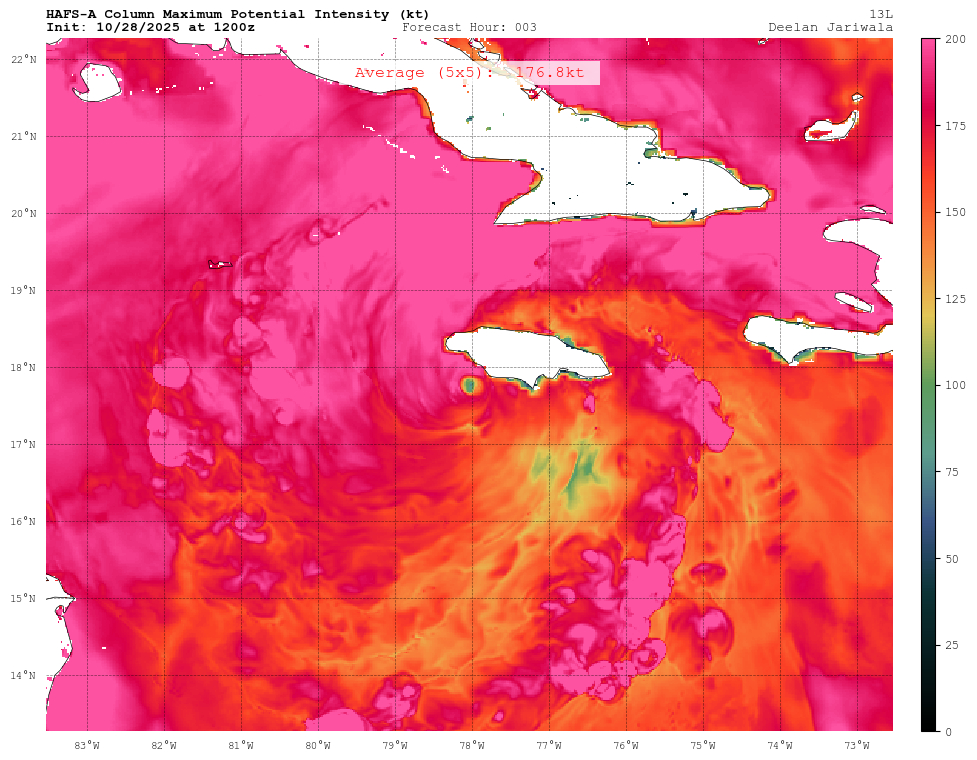

In [7]:
hafsPlot('13l', '10/28/2025', '1200', '3', 'mpi')#, 'none', 'a', t = 'parent')
